In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/reddit_preprocessing.csv')
df

,clean_comment,category,words_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0
...,...,...,...,...,...,...
36788,jesus,0,1,0,5,0
36789,kya bhai pure saal chutiya banaya modi aur jab...,1,19,0,99,0
36790,downvote karna tha par upvote hogaya,0,6,0,36,0
36791,haha nice,1,2,0,9,0


In [ ]:
df['clean_comment'].isna().sum()

np.int64(131)

In [ ]:
df.shape

(36793, 6)

In [ ]:
df[df['clean_comment'].isna()]

,clean_comment,category,words_count,num_stop_words,num_chars,num_punctuation_chars
287,NaN,0,1,1,5,0
821,NaN,0,2,2,8,0
922,NaN,0,1,1,3,0
934,NaN,0,27,0,69,0
1169,NaN,0,1,1,4,0
...,...,...,...,...,...,...
36358,NaN,0,2,0,10,0
36563,NaN,0,6,0,26,0
36599,NaN,0,16,0,72,0
36731,NaN,0,1,1,5,0


In [ ]:
df = df.dropna(subset=['clean_comment'])

In [ ]:
df[df['clean_comment'].isna()]

,clean_comment,category,words_count,num_stop_words,num_chars,num_punctuation_chars


# vectorizer

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000,stop_words='english',
    ngram_range=(1,2))

X = tfidf.fit_transform(df['clean_comment'])
y = df['category']

# Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

#classification report

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.813855175235238
              precision    recall  f1-score   support

          -1       0.83      0.61      0.71      1647
           0       0.77      0.94      0.85      2510
           1       0.85      0.82      0.83      3176

    accuracy                           0.81      7333
   macro avg       0.82      0.79      0.80      7333
weighted avg       0.82      0.81      0.81      7333



# confusion matrix

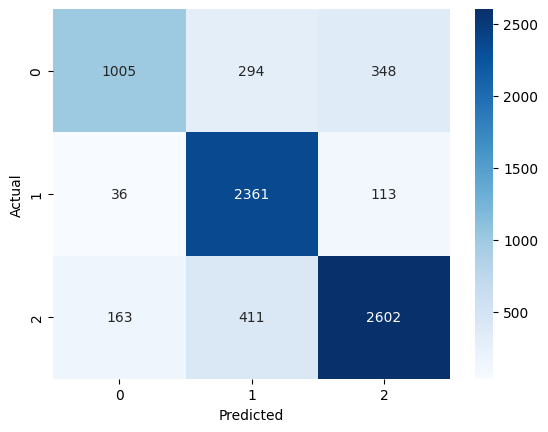

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# model download

In [ ]:
import pickle

pickle.dump(model, open("logistic_model.pkl", "wb"))
pickle.dump(tfidf, open("logistic_vectorizer.pkl", "wb"))

# testing model

In [ ]:
# testing the model manually
text = ["good luck"]

text_vec = tfidf.transform(text)

prediction = model.predict(text_vec)

print(prediction)

[1]
